# Multi-Dimensional Analysis of Two-Module Communication Regimes

This notebook performs comprehensive analysis across three dimensions:

1. **Task Regimes**: same, near, far (task similarity conditions)
2. **Communication Regimes**: none, low, high (inter-module communication levels)
3. **Embedding/Initialization Regimes**: rich_50, lazy_50, gamma_e_1_50 (learning dynamics)

## Configurations Analyzed

- **Rich embedding** (γ=1e-3): Fast learning, rich representations
  - `two_module_rich_50_{none,low,high}`
- **Lazy embedding** (γ=2): Slow learning, sparse representations
  - `two_module_lazy_50_{none,low,high}`
- **Intermediate embedding** (γ=0.1): Balanced learning dynamics
  - `two_module_gamma_e_1_50_{none,low,high}`

**Primary Focus**: Multi-dimensional comparison of task switching effects, learning dynamics, module activations, and representational geometry across all combinations of task similarity, communication strength, and embedding regimes.

In [12]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Setup path
SCRIPT_DIR = Path(__file__).parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent  # transfer-interference directory
sys.path.insert(0, str(PROJECT_ROOT))

# Imports from project
from src.analysis import ann
from src.utils import figure_settings, figure_utils
from src.utils.figure_settings import schedule_colours, cm_conv, med_fontsize

# Setup figure output
figure_path = PROJECT_ROOT / "figures" / "compare_communication_regimes"
os.makedirs(figure_path, exist_ok=True)

# Set style
plt.style.use("default")
sns.set_palette("husl")
print("✓ Imports completed")

✓ Imports completed


## 1. Setup and Data Loading

Load data from all three communication regime conditions.

In [13]:
# Define configuration names
configs = {
    'none': 'two_module_rich_50_none',
    'low': 'two_module_rich_50_low',
    'high': 'two_module_rich_50_high'
}

# Color scheme for conditions
comm_colors = {
    'none': '#808080',  # gray
    'low': '#56B4E9',   # blue
    'high': '#D9544D'   # red
}

# Load data for each condition
ann_data = {}
for comm_type, config_name in configs.items():
    data_path = PROJECT_ROOT / 'data' / 'simulations' / config_name
    if data_path.exists():
        ann_data[comm_type] = ann.load_ann_data(str(data_path))
        print(f"✓ Loaded {config_name}: {len(ann_data[comm_type]['same'])} participants")
    else:
        print(f"⚠ Warning: {data_path} does not exist")
        ann_data[comm_type] = {'same': [], 'near': [], 'far': []}

print(f"\nLoaded data for {len(ann_data)} communication regimes")

✓ Loaded two_module_rich_50_none: 103 participants
✓ Loaded two_module_rich_50_low: 103 participants
✓ Loaded two_module_rich_50_high: 103 participants

Loaded data for 3 communication regimes


## 2. Task Switching Analysis

Analyze transfer costs and interference at task boundaries (A1→B, B→A2).

Transfer metrics summary:
           count      mean       std       min       25%       50%       75%  \
comm_type                                                                      
high       305.0 -0.500598  0.116449 -0.772797 -0.584010 -0.500144 -0.415167   
low        305.0 -0.501309  0.115164 -0.781915 -0.580232 -0.499231 -0.417608   
none       305.0 -0.498755  0.122876 -0.811823 -0.584961 -0.498310 -0.407951   

                max  
comm_type            
high      -0.211273  
low       -0.215769  
none      -0.199660  

Retest metrics summary:
           count          mean           std           min           25%  \
comm_type                                                                  
high       305.0 -3.744774e-04  4.123241e-04 -1.212537e-03 -8.644462e-04   
low        305.0 -7.890307e-05  9.437802e-05 -3.015995e-04 -1.654029e-04   
none       305.0  3.048631e-07  3.765849e-07 -1.192093e-07  1.192093e-07   

                    50%           75%       max  
comm_ty

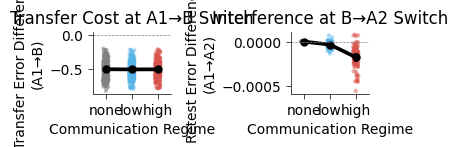

In [14]:
def compute_retest_metrics(ann_data_dict):
    """Compute retest/interference metrics (A1 vs A2 performance)."""
    agg_data = []
    
    for comm_type, data in ann_data_dict.items():
        for schedule_name, schedule_data in data.items():
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                # Get accuracy by task section (winter responses only, feature_idx==1)
                A1_accuracy = subj_data['accuracy'][0, 1::2].copy()  # Phase 0, every other (winter)
                A2_accuracy = subj_data['accuracy'][2, 1::2].copy()  # Phase 2, every other (winter)
                
                # Average over relevant windows
                final_A1_acc = np.mean(A1_accuracy[-6:])  # final 6 trials of A1
                initial_A2_acc = np.mean(A2_accuracy[0:6])  # first 6 trials of A2
                mean_A2_acc = np.mean(A2_accuracy)  # overall A2 performance
                
                # Calculate retest/interference metrics
                retest_error_diff = initial_A2_acc - final_A1_acc  # Initial A2 vs final A1
                interference = final_A1_acc - mean_A2_acc  # Final A1 vs mean A2
                
                agg_data.append({
                    'participant': str(subj_data['participant']),
                    'condition': schedule_name,
                    'comm_type': comm_type,
                    'final_A1_acc': final_A1_acc,
                    'initial_A2_acc': initial_A2_acc,
                    'mean_A2_acc': mean_A2_acc,
                    'retest_error_diff': retest_error_diff,
                    'interference': interference
                })
    
    return pd.DataFrame(agg_data)

# Compute transfer and retest metrics
transfer_dfs = {}
retest_dfs = {}

for comm_type, data in ann_data.items():
    if len(data['same']) > 0:  # Only if data exists
        transfer_dfs[comm_type] = ann.compute_transfer_anns(data)
        transfer_dfs[comm_type]['comm_type'] = comm_type

# Combine transfer data
if transfer_dfs:
    transfer_combined = pd.concat(transfer_dfs.values(), ignore_index=True)
    transfer_combined.rename(columns={'error_diff': 'transfer_error_diff'}, inplace=True)
    
    # Compute retest metrics
    retest_combined = compute_retest_metrics(ann_data)
    
    print("Transfer metrics summary:")
    print(transfer_combined.groupby('comm_type')['transfer_error_diff'].describe())
    print("\nRetest metrics summary:")
    print(retest_combined.groupby('comm_type')['retest_error_diff'].describe())
else:
    print("No data available for analysis")
if 'transfer_combined' in locals() and len(transfer_combined) > 0:
    # Define task regimes
    task_regimes = ['same', 'near', 'far']
    task_labels = ['Same', 'Near', 'Far']
    
    # Create multi-panel figure: rows = task regimes, columns = metrics
    fig, axes = plt.subplots(len(task_regimes), 2, figsize=(10*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    comm_order = ['none', 'low', 'high']
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        # Transfer error difference (A1→B)
        ax1 = axes[task_idx, 0]
        transfer_task = transfer_combined[transfer_combined['condition'] == task_regime]
        if len(transfer_task) > 0:
            sns.stripplot(data=transfer_task, x='comm_type', y='transfer_error_diff', 
                          ax=ax1, order=comm_order, palette=[comm_colors[c] for c in comm_order],
                          alpha=0.5, size=2, jitter=True, zorder=1)
            sns.pointplot(data=transfer_task, x='comm_type', y='transfer_error_diff',
                          ax=ax1, order=comm_order, color='black', markersize=3, zorder=2)
        ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        ax1.set_xlabel('Communication Regime')
        if task_idx == len(task_regimes) - 1:
            ax1.set_xlabel('Communication Regime')
        if task_idx == 0:
            ax1.set_title('Transfer Cost (A1→B)')
        if task_idx == 0:
            ax1.set_ylabel('Transfer Error\nDifference')
        else:
            ax1.set_ylabel(f'{task_label}\nTransfer Error')
        figure_utils._style_axes(ax1)
        
        # Retest error difference (A1→A2)
        ax2 = axes[task_idx, 1]
        retest_task = retest_combined[retest_combined['condition'] == task_regime]
        if len(retest_task) > 0:
            sns.stripplot(data=retest_task, x='comm_type', y='retest_error_diff',
                          ax=ax2, order=comm_order, palette=[comm_colors[c] for c in comm_order],
                          alpha=0.5, size=2, jitter=True, zorder=1)
            sns.pointplot(data=retest_task, x='comm_type', y='retest_error_diff',
                          ax=ax2, order=comm_order, color='black', markersize=3, zorder=2)
        ax2.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        ax2.set_xlabel('Communication Regime')
        if task_idx == len(task_regimes) - 1:
            ax2.set_xlabel('Communication Regime')
        if task_idx == 0:
            ax2.set_title('Interference (A1→A2)')
        if task_idx == 0:
            ax2.set_ylabel('Retest Error\nDifference')
        else:
            ax2.set_ylabel(f'{task_label}\nRetest Error')
        figure_utils._style_axes(ax2)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'task_switching_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No data available for visualization")

In [15]:
# Visualize transfer and retest metrics

In [16]:
def extract_learning_curves(ann_data_dict, phase_idx=0, metric='accuracy', feature_idx=1):
    """Extract learning curves for a specific phase, preserving task regime information."""
    curves = {}
    
    # Structure: curves[comm_type][task_regime] = list of curves
    for comm_type, data in ann_data_dict.items():
        curves[comm_type] = {}
        for schedule_name, schedule_data in data.items():
            curves[comm_type][schedule_name] = []
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                if metric == 'accuracy':
                    # Extract accuracy for specific feature (winter: feature_idx=1)
                    curve = subj_data['accuracy'][phase_idx, feature_idx::2].copy()
                elif metric == 'loss':
                    curve = subj_data['losses'][phase_idx, :].copy()
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                curves[comm_type][schedule_name].append(curve)
    
    return curves

# Extract learning curves for each phase
phases = {'A1': 0, 'B': 1, 'A2': 2}
learning_curves = {}

for phase_name, phase_idx in phases.items():
    learning_curves[phase_name] = {
        'accuracy': extract_learning_curves(ann_data, phase_idx, 'accuracy'),
        'loss': extract_learning_curves(ann_data, phase_idx, 'loss')
    }

print("Learning curves extracted for all phases")

Learning curves extracted for all phases


In [17]:
def extract_module_activations(ann_data_dict):
    """Extract module activation statistics per phase, preserving task regime information."""
    activation_stats = {}
    
    for comm_type, data in ann_data_dict.items():
        activation_stats[comm_type] = {}
        
        for schedule_name, schedule_data in data.items():
            activation_stats[comm_type][schedule_name] = {
                'A1': {'mod_A': [], 'mod_B': []},
                'B': {'mod_A': [], 'mod_B': []},
                'A2': {'mod_A': [], 'mod_B': []}
            }
            
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                # Check if per-module hidden states exist
                if 'hiddens_A' in subj_data and 'hiddens_B' in subj_data:
                    h_A = subj_data['hiddens_A']  # (n_phase, n_trials, dim_hidden_per_module)
                    h_B = subj_data['hiddens_B']
                    
                    for phase_idx, phase_name in enumerate(['A1', 'B', 'A2']):
                        if h_A.shape[0] > phase_idx:
                            # Compute activation magnitude (L2 norm) for each trial
                            mod_A_activations = np.linalg.norm(h_A[phase_idx, :, :], axis=1)
                            mod_B_activations = np.linalg.norm(h_B[phase_idx, :, :], axis=1)
                            
                            activation_stats[comm_type][schedule_name][phase_name]['mod_A'].append(mod_A_activations)
                            activation_stats[comm_type][schedule_name][phase_name]['mod_B'].append(mod_B_activations)
    
    return activation_stats

# Extract activation statistics
activation_stats = extract_module_activations(ann_data)
print("Module activation statistics extracted")

Module activation statistics extracted


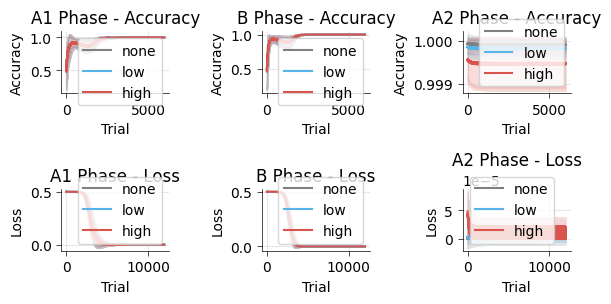

In [18]:
# Plot learning curves - split by task regime
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']

# Accuracy curves: rows = task regimes, columns = phases
fig_acc, axes_acc = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
if len(task_regimes) == 1:
    axes_acc = axes_acc.reshape(1, -1)

for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
    for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
        ax = axes_acc[task_idx, phase_idx]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in learning_curves[phase_name]['accuracy']:
                if task_regime in learning_curves[phase_name]['accuracy'][comm_type]:
                    curves = learning_curves[phase_name]['accuracy'][comm_type][task_regime]
                    if len(curves) > 0:
                        min_len = min(len(c) for c in curves)
                        curves_aligned = [c[:min_len] for c in curves]
                        curves_array = np.array(curves_aligned)
                        
                        mean_curve = np.mean(curves_array, axis=0)
                        std_curve = np.std(curves_array, axis=0)
                        x = np.arange(len(mean_curve))
                        
                        ax.plot(x, mean_curve, color=comm_colors[comm_type], 
                               label=comm_type, linewidth=1.5)
                        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                       color=comm_colors[comm_type], alpha=0.2)
        
        ax.set_xlabel('Trial')
        if task_idx == 0:
            ax.set_title(f'{phase_name} Phase')
        if phase_idx == 0:
            ax.set_ylabel(f'{task_label}\nAccuracy')
        else:
            ax.set_ylabel('Accuracy')
        if task_idx == 0 and phase_idx == len(phases) - 1:
            ax.legend()
        ax.grid(True, alpha=0.3)
        figure_utils._style_axes(ax)

plt.tight_layout()
plt.savefig(figure_path / 'learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Loss curves: rows = task regimes, columns = phases
fig_loss, axes_loss = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
if len(task_regimes) == 1:
    axes_loss = axes_loss.reshape(1, -1)

for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
    for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
        ax = axes_loss[task_idx, phase_idx]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in learning_curves[phase_name]['loss']:
                if task_regime in learning_curves[phase_name]['loss'][comm_type]:
                    curves = learning_curves[phase_name]['loss'][comm_type][task_regime]
                    if len(curves) > 0:
                        min_len = min(len(c) for c in curves)
                        curves_aligned = [c[:min_len] for c in curves]
                        curves_array = np.array(curves_aligned)
                        
                        mean_curve = np.mean(curves_array, axis=0)
                        std_curve = np.std(curves_array, axis=0)
                        x = np.arange(len(mean_curve))
                        
                        ax.plot(x, mean_curve, color=comm_colors[comm_type],
                               label=comm_type, linewidth=1.5)
                        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                       color=comm_colors[comm_type], alpha=0.2)
        
        ax.set_xlabel('Trial')
        if task_idx == 0:
            ax.set_title(f'{phase_name} Phase')
        if phase_idx == 0:
            ax.set_ylabel(f'{task_label}\nLoss')
        else:
            ax.set_ylabel('Loss')
        if task_idx == 0 and phase_idx == len(phases) - 1:
            ax.legend()
        ax.grid(True, alpha=0.3)
        figure_utils._style_axes(ax)

plt.tight_layout()
plt.savefig(figure_path / 'learning_curves_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Visualize module activations - split by task regime
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']
phases_list = ['A1', 'B', 'A2']

# Check if data exists
has_data = False
if activation_stats:
    for comm_type in activation_stats:
        for task_regime in task_regimes:
            if task_regime in activation_stats[comm_type]:
                if len(activation_stats[comm_type][task_regime]['A1']['mod_A']) > 0:
                    has_data = True
                    break
        if has_data:
            break

if has_data:
    fig, axes = plt.subplots(len(task_regimes), len(phases_list), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for phase_idx, phase_name in enumerate(phases_list):
            ax = axes[task_idx, phase_idx]
            
            # Collect data for grouped bar chart
            mod_A_means = []
            mod_A_stds = []
            mod_B_means = []
            mod_B_stds = []
            comm_types_present = []
            
            for comm_type in ['none', 'low', 'high']:
                if comm_type in activation_stats and task_regime in activation_stats[comm_type]:
                    if len(activation_stats[comm_type][task_regime][phase_name]['mod_A']) > 0:
                        all_A = np.concatenate(activation_stats[comm_type][task_regime][phase_name]['mod_A'])
                        all_B = np.concatenate(activation_stats[comm_type][task_regime][phase_name]['mod_B'])
                        
                        mod_A_means.append(np.mean(all_A))
                        mod_A_stds.append(np.std(all_A))
                        mod_B_means.append(np.mean(all_B))
                        mod_B_stds.append(np.std(all_B))
                        comm_types_present.append(comm_type)
            
            if len(comm_types_present) > 0:
                x = np.arange(len(comm_types_present))
                width = 0.35
                
                ax.bar(x - width/2, mod_A_means, width, yerr=mod_A_stds, 
                       label='Module A', color='#b08cca', alpha=0.7, capsize=5)
                ax.bar(x + width/2, mod_B_means, width, yerr=mod_B_stds,
                       label='Module B', color='#aad39b', alpha=0.7, capsize=5)
                
                ax.set_xticks(x)
                ax.set_xticklabels(comm_types_present)
                ax.set_ylabel('Activation Magnitude (L2 norm)')
                if task_idx == 0:
                    ax.set_title(f'{phase_name} Phase')
                if phase_idx == 0:
                    ax.set_ylabel(f'{task_label}\nActivation Magnitude')
                if task_idx == 0 and phase_idx == len(phases_list) - 1:
                    ax.legend()
                figure_utils._style_axes(ax)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'module_activations.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No module activation data available")

No module activation data available


## 5. Representational Geometry Analysis

Compare principal angles and PCA visualizations across communication regimes.

In [20]:
# Analyze cross-module activation (inactive module receiving communication)
def analyze_cross_module_activation(ann_data_dict):
    """Analyze how much inactive modules activate via communication."""
    cross_activation = {}
    
    for comm_type, data in ann_data_dict.items():
        cross_activation[comm_type] = {
            'A_active_B_receives': [],  # During A1/A2, how much does B activate?
            'B_active_A_receives': []   # During B, how much does A activate?
        }
        
        for schedule_name, schedule_data in data.items():
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                if 'hiddens_A' in subj_data and 'hiddens_B' in subj_data:
                    h_A = subj_data['hiddens_A']
                    h_B = subj_data['hiddens_B']
                    
                    # During A1/A2 (Module A active), measure Module B activation
                    for phase_idx in [0, 2]:  # A1 and A2
                        if h_B.shape[0] > phase_idx:
                            mod_B_acts = np.linalg.norm(h_B[phase_idx, :, :], axis=1)
                            cross_activation[comm_type]['A_active_B_receives'].extend(mod_B_acts)
                    
                    # During B (Module B active), measure Module A activation
                    if h_A.shape[0] > 1:
                        mod_A_acts = np.linalg.norm(h_A[1, :, :], axis=1)
                        cross_activation[comm_type]['B_active_A_receives'].extend(mod_A_acts)
    
    return cross_activation

cross_activation = analyze_cross_module_activation(ann_data)

# Visualize cross-module activation - split by task regime
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']

# Check if data exists
has_data = False
if cross_activation:
    for comm_type in cross_activation:
        for task_regime in task_regimes:
            if task_regime in cross_activation[comm_type]:
                if len(cross_activation[comm_type][task_regime]['A_active_B_receives']) > 0:
                    has_data = True
                    break
        if has_data:
            break

if has_data:
    fig, axes = plt.subplots(len(task_regimes), 2, figsize=(10*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        # Module B activation when A is active
        ax1 = axes[task_idx, 0]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in cross_activation and task_regime in cross_activation[comm_type]:
                if len(cross_activation[comm_type][task_regime]['A_active_B_receives']) > 0:
                    acts = cross_activation[comm_type][task_regime]['A_active_B_receives']
                    mean_act = np.mean(acts)
                    std_act = np.std(acts)
                    ax1.bar(comm_type, mean_act, color=comm_colors[comm_type], alpha=0.7,
                           yerr=std_act, capsize=5)
        ax1.set_ylabel('Module B Activation\n(when A is active)')
        if task_idx == 0:
            ax1.set_title('Cross-Module Communication: A→B')
        if task_idx == 0:
            ax1.set_ylabel('Module B Activation\n(when A is active)')
        else:
            ax1.set_ylabel(f'{task_label}\nModule B Activation')
        ax1.set_xticklabels(['none', 'low', 'high'])
        figure_utils._style_axes(ax1)
        
        # Module A activation when B is active
        ax2 = axes[task_idx, 1]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in cross_activation and task_regime in cross_activation[comm_type]:
                if len(cross_activation[comm_type][task_regime]['B_active_A_receives']) > 0:
                    acts = cross_activation[comm_type][task_regime]['B_active_A_receives']
                    mean_act = np.mean(acts)
                    std_act = np.std(acts)
                    ax2.bar(comm_type, mean_act, color=comm_colors[comm_type], alpha=0.7,
                           yerr=std_act, capsize=5)
        ax2.set_ylabel('Module A Activation\n(when B is active)')
        if task_idx == 0:
            ax2.set_title('Cross-Module Communication: B→A')
        if task_idx == 0:
            ax2.set_ylabel('Module A Activation\n(when B is active)')
        else:
            ax2.set_ylabel(f'{task_label}\nModule A Activation')
        ax2.set_xticklabels(['none', 'low', 'high'])
        figure_utils._style_axes(ax2)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'cross_module_activation.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No cross-module activation data available")

No cross-module activation data available


Principal angles summary:
          within_task_A                                                        \
                  count       mean        std       min        25%        50%   
comm_type                                                                       
high              305.0  38.953194  18.017641  0.094873  25.649914  43.246090   
low               305.0  38.971012  18.016083  0.081565  25.558149  43.227539   
none              305.0  38.153896  17.616064  0.100871  27.202267  42.130772   

                                within_task_B             ...             \
                 75%        max         count       mean  ...        75%   
comm_type                                                 ...              
high       52.258842  73.640694         305.0  39.172005  ...  51.865433   
low        52.151031  73.610107         305.0  39.207676  ...  51.915459   
none       51.733665  71.842308         305.0  38.471516  ...  51.650715   

                     across_ta

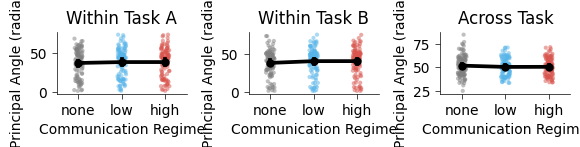

In [21]:
# Compute principal angles for each condition
principal_angles = {}

for comm_type, data in ann_data.items():
    if len(data['same']) > 0:
        pa_df = ann.get_principal_angles(data)
        pa_df['comm_type'] = comm_type
        principal_angles[comm_type] = pa_df

# Combine principal angle data
if principal_angles:
    pa_combined = pd.concat(principal_angles.values(), ignore_index=True)
    
    print("Principal angles summary:")
    print(pa_combined.groupby('comm_type')[['within_task_A', 'within_task_B', 'across_task']].describe())
    
    # Visualize principal angles - split by task regime
    task_regimes = ['same', 'near', 'far']
    task_labels = ['Same', 'Near', 'Far']
    metrics = ['within_task_A', 'within_task_B', 'across_task']
    metric_labels = ['Within Task A', 'Within Task B', 'Across Task']
    
    fig, axes = plt.subplots(len(task_regimes), len(metrics), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for metric_idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
            ax = axes[task_idx, metric_idx]
            pa_task = pa_combined[pa_combined['condition'] == task_regime]
            if len(pa_task) > 0:
                sns.stripplot(data=pa_task, x='comm_type', y=metric,
                             ax=ax, order=['none', 'low', 'high'],
                             palette=[comm_colors[c] for c in ['none', 'low', 'high']],
                             alpha=0.5, size=2, jitter=True, zorder=1)
                sns.pointplot(data=pa_task, x='comm_type', y=metric,
                             ax=ax, order=['none', 'low', 'high'],
                             color='black', markersize=3, zorder=2)
            ax.set_xlabel('Communication Regime')
            if task_idx == 0:
                ax.set_title(label)
            if metric_idx == 0:
                ax.set_ylabel(f'{task_label}\nPrincipal Angle')
            else:
                ax.set_ylabel('Principal Angle')
            figure_utils._style_axes(ax)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'principal_angles.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No principal angle data available")

## 6. Statistical Comparisons

Perform statistical tests comparing communication regimes.

In [22]:
def compute_effect_size(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    d = (mean1 - mean2) / pooled_std
    return d

# Statistical comparisons
if 'transfer_combined' in locals() and len(transfer_combined) > 0:
    print("=" * 60)
    print("STATISTICAL COMPARISONS")
    print("=" * 60)
    
    # Transfer cost comparisons
    print("\n1. Transfer Cost (A1→B) Comparisons:")
    print("-" * 60)
    
    transfer_same = transfer_combined[transfer_combined['condition'] == 'same']
    
    for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
        g1 = transfer_same[transfer_same['comm_type'] == comparison[0]]['transfer_error_diff'].values
        g2 = transfer_same[transfer_same['comm_type'] == comparison[1]]['transfer_error_diff'].values
        
        if len(g1) > 0 and len(g2) > 0:
            t_stat, p_val = stats.ttest_ind(g1, g2)
            effect_size = compute_effect_size(g1, g2)
            
            print(f"{comparison[0]} vs {comparison[1]}:")
            print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
            print(f"  Effect size (Cohen's d): {effect_size:.3f}")
            print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
            print()
    
    # Retest/interference comparisons
    if 'retest_combined' in locals() and len(retest_combined) > 0:
        print("\n2. Retest/Interference (A1→A2) Comparisons:")
        print("-" * 60)
        
        retest_same = retest_combined[retest_combined['condition'] == 'same']
        
        for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
            g1 = retest_same[retest_same['comm_type'] == comparison[0]]['retest_error_diff'].values
            g2 = retest_same[retest_same['comm_type'] == comparison[1]]['retest_error_diff'].values
            
            if len(g1) > 0 and len(g2) > 0:
                t_stat, p_val = stats.ttest_ind(g1, g2)
                effect_size = compute_effect_size(g1, g2)
                
                print(f"{comparison[0]} vs {comparison[1]}:")
                print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
                print(f"  Effect size (Cohen's d): {effect_size:.3f}")
                print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
                print()
    
    # Principal angle comparisons
    if 'pa_combined' in locals() and len(pa_combined) > 0:
        print("\n3. Principal Angle Comparisons (Across-Task):")
        print("-" * 60)
        
        pa_same = pa_combined[pa_combined['condition'] == 'same']
        
        for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
            g1 = pa_same[pa_same['comm_type'] == comparison[0]]['across_task'].values
            g2 = pa_same[pa_same['comm_type'] == comparison[1]]['across_task'].values
            
            if len(g1) > 0 and len(g2) > 0:
                t_stat, p_val = stats.ttest_ind(g1, g2)
                effect_size = compute_effect_size(g1, g2)
                
                print(f"{comparison[0]} vs {comparison[1]}:")
                print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
                print(f"  Effect size (Cohen's d): {effect_size:.3f}")
                print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
                print()
else:
    print("No data available for statistical comparisons")

STATISTICAL COMPARISONS

1. Transfer Cost (A1→B) Comparisons:
------------------------------------------------------------
none vs low:
  t-statistic: 0.373, p-value: 0.7096
  Effect size (Cohen's d): 0.052
  Mean difference: 0.0063

none vs high:
  t-statistic: 0.252, p-value: 0.8012
  Effect size (Cohen's d): 0.035
  Mean difference: 0.0043

low vs high:
  t-statistic: -0.123, p-value: 0.9026
  Effect size (Cohen's d): -0.017
  Mean difference: -0.0020


2. Retest/Interference (A1→A2) Comparisons:
------------------------------------------------------------
none vs low:
  t-statistic: 10.340, p-value: 0.0000
  Effect size (Cohen's d): 1.441
  Mean difference: 0.0000

none vs high:
  t-statistic: 14.405, p-value: 0.0000
  Effect size (Cohen's d): 2.007
  Mean difference: 0.0002

low vs high:
  t-statistic: 11.274, p-value: 0.0000
  Effect size (Cohen's d): 1.571
  Mean difference: 0.0001


3. Principal Angle Comparisons (Across-Task):
--------------------------------------------------

In [23]:
# Create summary table
if 'transfer_combined' in locals() and 'retest_combined' in locals():
    summary_data = []
    
    for comm_type in ['none', 'low', 'high']:
        # Transfer metrics
        transfer_subset = transfer_combined[
            (transfer_combined['comm_type'] == comm_type) & 
            (transfer_combined['condition'] == 'same')
        ]
        
        # Retest metrics
        retest_subset = retest_combined[
            (retest_combined['comm_type'] == comm_type) &
            (retest_combined['condition'] == 'same')
        ]
        
        if len(transfer_subset) > 0 and len(retest_subset) > 0:
            summary_data.append({
                'Communication Regime': comm_type,
                'Transfer Cost (A1→B)': f"{np.mean(transfer_subset['transfer_error_diff']):.4f} ± {np.std(transfer_subset['transfer_error_diff']):.4f}",
                'Interference (A1→A2)': f"{np.mean(retest_subset['retest_error_diff']):.4f} ± {np.std(retest_subset['retest_error_diff']):.4f}",
                'Final A1 Accuracy': f"{np.mean(retest_subset['final_A1_acc']):.4f} ± {np.std(retest_subset['final_A1_acc']):.4f}",
                'Mean A2 Accuracy': f"{np.mean(retest_subset['mean_A2_acc']):.4f} ± {np.std(retest_subset['mean_A2_acc']):.4f}",
            })
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        print("=" * 80)
        print("SUMMARY TABLE")
        print("=" * 80)
        print(summary_df.to_string(index=False))
        print()
        
        # Key insights
        print("=" * 80)
        print("KEY INSIGHTS")
        print("=" * 80)
        print("\n1. Transfer Cost (A1→B):")
        print("   - Measures performance drop when switching from Task A to Task B")
        print("   - Lower (more negative) values indicate better transfer")
        print("   - Communication may help Module B leverage Module A's knowledge")
        
        print("\n2. Interference (A1→A2):")
        print("   - Measures performance change when returning to Task A after B training")
        print("   - Negative values indicate catastrophic forgetting")
        print("   - Communication may help preserve Module A representations during B training")
        
        print("\n3. Communication Effects:")
        print("   - None: Modules are completely isolated")
        print("   - Low: Minimal information flow (scale=0.05)")
        print("   - High: Strong information flow (scale=0.1)")
        
        print("\n4. Questions to Consider:")
        print("   - Does communication reduce transfer cost?")
        print("   - Does communication prevent catastrophic forgetting?")
        print("   - Are there trade-offs between transfer and interference?")
        print("   - How does communication strength affect these metrics?")
    else:
        print("No summary data available")
else:
    print("No data available for summary")

SUMMARY TABLE
Communication Regime Transfer Cost (A1→B) Interference (A1→A2) Final A1 Accuracy Mean A2 Accuracy
                none     -0.4966 ± 0.1238      0.0000 ± 0.0000   0.9999 ± 0.0001  0.9999 ± 0.0001
                 low     -0.5029 ± 0.1178     -0.0000 ± 0.0000   0.9999 ± 0.0001  0.9999 ± 0.0001
                high     -0.5009 ± 0.1188     -0.0002 ± 0.0001   0.9999 ± 0.0001  0.9998 ± 0.0001

KEY INSIGHTS

1. Transfer Cost (A1→B):
   - Measures performance drop when switching from Task A to Task B
   - Lower (more negative) values indicate better transfer
   - Communication may help Module B leverage Module A's knowledge

2. Interference (A1→A2):
   - Measures performance change when returning to Task A after B training
   - Negative values indicate catastrophic forgetting
   - Communication may help preserve Module A representations during B training

3. Communication Effects:
   - None: Modules are completely isolated
   - Low: Minimal information flow (scale=0.05)
   - Hi

## 7. Summary and Insights

Summary table of key metrics and interpretation of communication effects.